In [3]:
import random
random.seed(42)

In [4]:
import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import weight_norm
from torch.nn.utils.parametrize import remove_parametrizations
import seaborn as sns

In [5]:
import os
import pandas as pd
import numpy as np
import shutil
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from optuna.importance import get_param_importances
from optuna.importance import MeanDecreaseImpurityImportanceEvaluator
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

import lightgbm as lgb
import optuna

import math

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


In [6]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [7]:
sns.set_theme(style="whitegrid", palette="rocket")

## TCN architecture

In [6]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = dilation * (kernel_size - 1)
        self.conv = weight_norm(nn.Conv1d(in_channels, out_channels, kernel_size, padding=self.padding, dilation=dilation))

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

In [8]:
batch_size = 1
in_channels = 2
sequence_length = 4
mock_input = torch.randn(batch_size, in_channels, sequence_length)

conv_layer = CausalConv1d(in_channels=2, out_channels=16, kernel_size=3, dilation=2)

output = conv_layer(mock_input)

print(output)

tensor([[[ 0.1154,  0.1102,  0.2069,  0.1553],
         [-0.2136, -0.3765, -0.7777, -0.2420],
         [-0.2203, -0.2333, -0.5213, -0.3372],
         [ 0.0301, -0.1037, -0.3705, -0.0149],
         [ 0.3221,  0.1192, -0.5922,  0.1590],
         [-0.1123, -0.3031, -0.1805, -0.1261],
         [-0.1283, -0.1594, -0.1962, -0.1252],
         [-0.0779, -0.2149, -0.7878, -0.2096],
         [ 0.3885,  0.0901, -0.2124,  0.2689],
         [ 0.3390, -0.0418, -0.2646,  0.2353],
         [ 0.3334,  0.0424, -0.3162,  0.2435],
         [ 0.1629, -0.1856, -1.2368, -0.0820],
         [-0.5628, -0.3208,  0.1215, -0.4667],
         [ 0.3312, -0.1164, -0.9337,  0.0988],
         [ 0.1552, -0.0947, -0.7446,  0.0371],
         [-0.5291, -0.3826, -0.7696, -0.5587]]], grad_fn=<SliceBackward0>)


In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, dropout=0.2):
        super(ResidualBlock, self).__init__()
        
        self.optional_conv = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None

        self.causal_conv1 = CausalConv1d(in_channels, out_channels, kernel_size, dilation)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=dropout)

        self.causal_conv2 = CausalConv1d(out_channels, out_channels, kernel_size, dilation)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=dropout)

        self.residual = nn.Sequential(self.causal_conv1, self.relu1, self.dropout1, 
                                      self.causal_conv2, self.relu2, self.dropout2)

        # self.relu = nn.ReLU()

    def forward(self, x):
        res = self.residual(x)
        x_conv = self.optional_conv(x) if self.optional_conv is not None else x
        # out = self.relu(x_conv + res)
        out = x_conv + res
        return out

In [10]:
batch_size = 1
in_channels = 2
sequence_length = 4
mock_input = torch.randn(batch_size, in_channels, sequence_length)
print(mock_input)

conv_layer = ResidualBlock(in_channels=2, out_channels=16, kernel_size=3, dilation=2)

output = conv_layer(mock_input)
print(output)

tensor([[[-0.6556,  0.8576, -1.6270, -1.3951],
         [-0.2387, -0.5050, -2.4752, -0.9316]]])
tensor([[[-0.4835, -0.7076, -0.6952, -0.4955],
         [-0.1234,  0.4016, -1.7547, -0.7889],
         [ 0.2589,  1.3829,  0.8947,  0.3450],
         [-0.7098, -0.3595,  0.1420, -0.4974],
         [ 0.3414,  0.3650,  1.6456,  0.7654],
         [ 0.0669,  1.1797,  0.6019, -0.0498],
         [-0.1789,  0.3268, -1.1017, -0.6305],
         [-0.3112,  0.1383,  0.3452, -0.2162],
         [-0.0894,  0.8418, -1.0147, -0.3730],
         [ 0.4607,  0.7643,  1.9074,  0.8252],
         [ 0.0951,  0.5725,  0.0440, -0.0509],
         [-0.0569, -0.7088, -1.1005, -0.2381],
         [-0.1313,  0.1910,  0.5246, -0.0427],
         [ 0.3516, -0.1467,  0.8194,  0.6064],
         [-0.2225,  0.4305, -0.2644, -0.5074],
         [ 0.1792, -0.4344,  1.5683,  1.1662]]], grad_fn=<AddBackward0>)


In [8]:
class TCN(nn.Module):
    def __init__(self, in_channels, out_channels, levels, kernel_size, dropout=0.2):
        super(TCN, self).__init__()
        layers = []
        for i in range(levels):
            dilation = 2 ** i
            now_num_channels = in_channels if i == 0 else out_channels[i - 1]
            now_out_channels = out_channels[i]
            layers += [ResidualBlock(now_num_channels, now_out_channels, kernel_size, dilation, dropout)]

        self.tcn = nn.Sequential(*layers)
        self.linear = nn.Linear(out_channels[-1], 1)
        # self.sigmoid = nn.Sigmoid() # think about it

    def forward(self, x):
        x = self.tcn(x)
        # print(f"1: {x}")
        # last_step_features = x[:, :, -1]
        # print(f"2: {last_step_features}")
        x = x.transpose(1, 2)
        x = self.linear(x)
        # print(f"3: {x}")
        # x = self.sigmoid(x)
        # print(f"4: {x}")
        return x        

In [12]:
batch_size = 1
in_channels = 2
sequence_length = 4
mock_input = torch.randn(batch_size, in_channels, sequence_length)
print(mock_input)

conv_layer = TCN(in_channels=2, out_channels=[16, 64, 128], levels=3, kernel_size=3)

output = conv_layer(mock_input)
print(output)

tensor([[[-0.2791,  0.6056, -2.1993,  0.1010],
         [-1.7474,  0.4997, -1.2637,  0.1965]]])
tensor([[[ 0.0452],
         [-0.0550],
         [-0.2461],
         [-0.1192]]], grad_fn=<AddBackward0>)


## Necessary Features 

In [9]:
df=pd.read_csv('/kaggle/input/processed-sepsis-dataset/processed_dataset_v2.psv', sep="|")

In [10]:
df_1 = df

In [11]:
df_columns = df.columns.tolist()

In [12]:
df_columns

['id',
 'HR',
 'O2Sat',
 'Temp',
 'SBP',
 'MAP',
 'DBP',
 'Resp',
 'EtCO2',
 'BaseExcess',
 'HCO3',
 'FiO2',
 'pH',
 'PaCO2',
 'SaO2',
 'AST',
 'BUN',
 'Alkalinephos',
 'Calcium',
 'Chloride',
 'Creatinine',
 'Bilirubin_direct',
 'Glucose',
 'Lactate',
 'Magnesium',
 'Phosphate',
 'Potassium',
 'Bilirubin_total',
 'TroponinI',
 'Hct',
 'Hgb',
 'PTT',
 'WBC',
 'Fibrinogen',
 'Platelets',
 'Age',
 'Gender',
 'Unit1',
 'Unit2',
 'HospAdmTime',
 'ICULOS',
 'SepsisLabel',
 'HR_missing',
 'O2Sat_missing',
 'Temp_missing',
 'SBP_missing',
 'MAP_missing',
 'DBP_missing',
 'Resp_missing',
 'EtCO2_missing',
 'BaseExcess_missing',
 'HCO3_missing',
 'FiO2_missing',
 'pH_missing',
 'PaCO2_missing',
 'SaO2_missing',
 'AST_missing',
 'BUN_missing',
 'Alkalinephos_missing',
 'Calcium_missing',
 'Chloride_missing',
 'Creatinine_missing',
 'Bilirubin_direct_missing',
 'Glucose_missing',
 'Lactate_missing',
 'Magnesium_missing',
 'Phosphate_missing',
 'Potassium_missing',
 'Bilirubin_total_missing',
 'Tr

In [12]:
df_col_wo_windows = df_columns[0:76] #для тестів без вікон

In [18]:
df_col_wo_windows

['id',
 'HR',
 'O2Sat',
 'Temp',
 'SBP',
 'MAP',
 'DBP',
 'Resp',
 'EtCO2',
 'BaseExcess',
 'HCO3',
 'FiO2',
 'pH',
 'PaCO2',
 'SaO2',
 'AST',
 'BUN',
 'Alkalinephos',
 'Calcium',
 'Chloride',
 'Creatinine',
 'Bilirubin_direct',
 'Glucose',
 'Lactate',
 'Magnesium',
 'Phosphate',
 'Potassium',
 'Bilirubin_total',
 'TroponinI',
 'Hct',
 'Hgb',
 'PTT',
 'WBC',
 'Fibrinogen',
 'Platelets',
 'Age',
 'Gender',
 'Unit1',
 'Unit2',
 'HospAdmTime',
 'ICULOS',
 'SepsisLabel',
 'HR_missing',
 'O2Sat_missing',
 'Temp_missing',
 'SBP_missing',
 'MAP_missing',
 'DBP_missing',
 'Resp_missing',
 'EtCO2_missing',
 'BaseExcess_missing',
 'HCO3_missing',
 'FiO2_missing',
 'pH_missing',
 'PaCO2_missing',
 'SaO2_missing',
 'AST_missing',
 'BUN_missing',
 'Alkalinephos_missing',
 'Calcium_missing',
 'Chloride_missing',
 'Creatinine_missing',
 'Bilirubin_direct_missing',
 'Glucose_missing',
 'Lactate_missing',
 'Magnesium_missing',
 'Phosphate_missing',
 'Potassium_missing',
 'Bilirubin_total_missing',
 'Tr

In [13]:
df_col_wo_windows += ['ShockIndex', 'BUN/CR'] 

In [22]:
df_col_wo_windows

['id',
 'HR',
 'O2Sat',
 'Temp',
 'SBP',
 'MAP',
 'DBP',
 'Resp',
 'EtCO2',
 'BaseExcess',
 'HCO3',
 'FiO2',
 'pH',
 'PaCO2',
 'SaO2',
 'AST',
 'BUN',
 'Alkalinephos',
 'Calcium',
 'Chloride',
 'Creatinine',
 'Bilirubin_direct',
 'Glucose',
 'Lactate',
 'Magnesium',
 'Phosphate',
 'Potassium',
 'Bilirubin_total',
 'TroponinI',
 'Hct',
 'Hgb',
 'PTT',
 'WBC',
 'Fibrinogen',
 'Platelets',
 'Age',
 'Gender',
 'Unit1',
 'Unit2',
 'HospAdmTime',
 'ICULOS',
 'SepsisLabel',
 'HR_missing',
 'O2Sat_missing',
 'Temp_missing',
 'SBP_missing',
 'MAP_missing',
 'DBP_missing',
 'Resp_missing',
 'EtCO2_missing',
 'BaseExcess_missing',
 'HCO3_missing',
 'FiO2_missing',
 'pH_missing',
 'PaCO2_missing',
 'SaO2_missing',
 'AST_missing',
 'BUN_missing',
 'Alkalinephos_missing',
 'Calcium_missing',
 'Chloride_missing',
 'Creatinine_missing',
 'Bilirubin_direct_missing',
 'Glucose_missing',
 'Lactate_missing',
 'Magnesium_missing',
 'Phosphate_missing',
 'Potassium_missing',
 'Bilirubin_total_missing',
 'Tr

In [74]:
# df = df[df_col]

In [75]:
# df

,id,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,HR_missing,O2Sat_missing,Temp_missing,SBP_missing,MAP_missing,DBP_missing,Resp_missing,EtCO2_missing,BaseExcess_missing,HCO3_missing,FiO2_missing,pH_missing,PaCO2_missing,SaO2_missing,AST_missing,BUN_missing,Alkalinephos_missing,Calcium_missing,Chloride_missing,Creatinine_missing,Bilirubin_direct_missing,Glucose_missing,Lactate_missing,Magnesium_missing,Phosphate_missing,Potassium_missing,Bilirubin_total_missing,TroponinI_missing,Hct_missing,Hgb_missing,PTT_missing,WBC_missing,Fibrinogen_missing,Platelets_missing,ShockIndex,BUN/CR
0,p000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,NaN,NaN
1,p000001,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,0,0,1,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.989796,NaN
2,p000001,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,0,0,1,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.729508,NaN
3,p000001,90.0,95.0,NaN,122.0,86.00,NaN,30.0,NaN,24.0,NaN,NaN,7.36,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,0,0,1,1,1,1,0,1,0,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.737705,NaN
4,p000001,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,24.0,NaN,0.28,7.36,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,0,0,1,0,0,1,0,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.844262,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,p120000,80.0,96.0,36.4,115.0,87.00,65.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,11.0,75.0,8.9,NaN,0.54,0.1,239.0,NaN,2.2,4.0,3.6,0.9,NaN,37.1,11.6,29.1,5.4,NaN,216.0,62.00,0,NaN,NaN,0.00,31,0,0,0,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.695652,20.37037
1552206,p120000,74.0,97.0,36.4,114.0,83.00,67.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,11.0,75.0,8.9,NaN,0.54,0.1,239.0,NaN,2.2,4.0,3.6,0.9,NaN,37.1,11.6,29.1,5.4,NaN,216.0,62.00,0,NaN,NaN,0.00,32,0,0,0,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.649123,20.37037
1552207,p120000,78.0,98.0,36.4,110.0,83.00,69.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,11.0,75.0,8.9,NaN,0.54,0.1,239.0,NaN,2.2,4.0,3.6,0.9,NaN,37.1,11.6,29.1,5.4,NaN,216.0,62.00,0,NaN,NaN,0.00,33,0,0,0,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.709091,20.37037
1552208,p120000,82.0,99.0,36.6,124.0,91.00,71.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,11.0,75.0,8.9,NaN,0.54,0.1,242.0,NaN,2.2,4.0,3.6,0.9,NaN,37.1,11.6,29.1,5.4,NaN,216.0,62.00,0,NaN,NaN,0.00,34,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,0.661290,20.37037


In [14]:
df = df.sort_values(['id', 'ICULOS'])

ids = df['id'].unique()

ratio = 0.15 / 0.90

train_val_ids, test_ids = train_test_split(ids, test_size=0.10, random_state=42)

train_ids, val_ids = train_test_split(train_val_ids, test_size=ratio, random_state=42)

print(f"{set(train_ids) & set(val_ids)}")
print(f"{set(train_ids) & set(test_ids)}")
print(f"{set(val_ids) & set(test_ids)}")

total = len(ids)
print(f"\nTrain: {len(train_ids)/total:.2%}")
print(f"Val:   {len(val_ids)/total:.2%}")
print(f"Test:  {len(test_ids)/total:.2%}")

train_df = df[df['id'].isin(train_ids)].copy()
val_df   = df[df['id'].isin(val_ids)].copy()
test_df  = df[df['id'].isin(test_ids)].copy()

set()
set()
set()

Train: 75.00%
Val:   15.00%
Test:  10.00%


In [15]:
pd.set_option('display.max_columns', None)

In [17]:
train_df[train_df['id'] == 'p000003']

,id,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,HR_missing,O2Sat_missing,Temp_missing,SBP_missing,MAP_missing,DBP_missing,Resp_missing,EtCO2_missing,BaseExcess_missing,HCO3_missing,FiO2_missing,pH_missing,PaCO2_missing,SaO2_missing,AST_missing,BUN_missing,Alkalinephos_missing,Calcium_missing,Chloride_missing,Creatinine_missing,Bilirubin_direct_missing,Glucose_missing,Lactate_missing,Magnesium_missing,Phosphate_missing,Potassium_missing,Bilirubin_total_missing,TroponinI_missing,Hct_missing,Hgb_missing,PTT_missing,WBC_missing,Fibrinogen_missing,Platelets_missing,Lactate_Freq_6h,Lactate_Freq_12h,Lactate_Mean_6h,Lactate_Mean_12h,FiO2_Freq_6h,FiO2_Freq_12h,FiO2_Mean_6h,FiO2_Mean_12h,PaCO2_Freq_6h,PaCO2_Freq_12h,PaCO2_Mean_6h,PaCO2_Mean_12h,pH_Freq_6h,pH_Freq_12h,pH_Mean_6h,pH_Mean_12h,BaseExcess_Freq_6h,BaseExcess_Freq_12h,BaseExcess_Mean_6h,BaseExcess_Mean_12h,Alkalinephos_Freq_6h,Alkalinephos_Freq_12h,Alkalinephos_Mean_6h,Alkalinephos_Mean_12h,AST_Freq_6h,AST_Freq_12h,AST_Mean_6h,AST_Mean_12h,Bilirubin_total_Freq_6h,Bilirubin_total_Freq_12h,Bilirubin_total_Mean_6h,Bilirubin_total_Mean_12h,SaO2_Freq_6h,SaO2_Freq_12h,SaO2_Mean_6h,SaO2_Mean_12h,PTT_Freq_6h,PTT_Freq_12h,PTT_Mean_6h,PTT_Mean_12h,Chloride_Freq_6h,Chloride_Freq_12h,Chloride_Mean_6h,Chloride_Mean_12h,Phosphate_Freq_6h,Phosphate_Freq_12h,Phosphate_Mean_6h,Phosphate_Mean_12h,EtCO2_Freq_6h,EtCO2_Freq_12h,EtCO2_Mean_6h,EtCO2_Mean_12h,ShockIndex,BUN/CR,HR_Min_2h,HR_Max_2h,HR_Mean_2h,HR_Std_2h,HR_Min_6h,HR_Min_3h,HR_Max_3h,HR_Mean_3h,HR_Std_3h,HR_Max_6h,HR_Mean_6h,HR_Std_6h,HR_Min_12h,HR_Max_12h,HR_Mean_12h,HR_Std_12h,O2Sat_Min_2h,O2Sat_Max_2h,O2Sat_Mean_2h,O2Sat_Std_2h,O2Sat_Min_6h,O2Sat_Min_3h,O2Sat_Max_3h,O2Sat_Mean_3h,O2Sat_Std_3h,O2Sat_Max_6h,O2Sat_Mean_6h,O2Sat_Std_6h,O2Sat_Min_12h,O2Sat_Max_12h,O2Sat_Mean_12h,O2Sat_Std_12h,Temp_Min_2h,Temp_Max_2h,Temp_Mean_2h,Temp_Std_2h,Temp_Min_6h,Temp_Min_3h,Temp_Max_3h,Temp_Mean_3h,Temp_Std_3h,Temp_Max_6h,Temp_Mean_6h,Temp_Std_6h,Temp_Min_12h,Temp_Max_12h,Temp_Mean_12h,Temp_Std_12h,SBP_Min_2h,SBP_Max_2h,SBP_Mean_2h,SBP_Std_2h,SBP_Min_6h,SBP_Min_3h,SBP_Max_3h,SBP_Mean_3h,SBP_Std_3h,SBP_Max_6h,SBP_Mean_6h,SBP_Std_6h,SBP_Min_12h,SBP_Max_12h,SBP_Mean_12h,SBP_Std_12h,MAP_Min_2h,MAP_Max_2h,MAP_Mean_2h,MAP_Std_2h,MAP_Min_6h,MAP_Min_3h,MAP_Max_3h,MAP_Mean_3h,MAP_Std_3h,MAP_Max_6h,MAP_Mean_6h,MAP_Std_6h,MAP_Min_12h,MAP_Max_12h,MAP_Mean_12h,MAP_Std_12h,DBP_Min_2h,DBP_Max_2h,DBP_Mean_2h,DBP_Std_2h,DBP_Min_6h,DBP_Min_3h,DBP_Max_3h,DBP_Mean_3h,DBP_Std_3h,DBP_Max_6h,DBP_Mean_6h,DBP_Std_6h,DBP_Min_12h,DBP_Max_12h,DBP_Mean_12h,DBP_Std_12h,Resp_Min_2h,Resp_Max_2h,Resp_Mean_2h,Resp_Std_2h,Resp_Min_6h,Resp_Min_3h,Resp_Max_3h,Resp_Mean_3h,Resp_Std_3h,Resp_Max_6h,Resp_Mean_6h,Resp_Std_6h,Resp_Min_12h,Resp_Max_12h,Resp_Mean_12h,Resp_Std_12h
77,p000003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.82,0,1.0,0.0,-1195.71,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,p000003,87.0,96.0,NaN,131.0,70.33,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN,Na

## Data preprocessing

In [16]:
class SepsisDataset(Dataset):
    def __init__(self, df, colm):
        self.colm = colm
        self.ids = df['id'].unique()
        self.grouped = [group for _, group in df.groupby('id')]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        patient_data = self.grouped[idx]
        features = torch.tensor(patient_data[self.colm].values, dtype=torch.float32)
        labels = torch.tensor(patient_data['SepsisLabel'].values, dtype=torch.float32)
        return features, labels

In [17]:
def collate_batch(batch):
    features = [item[0] for item in batch]
    features = pad_sequence(features, batch_first=True, padding_value=-999)
    features = features.transpose(1, 2)
    
    labels = [item[1] for item in batch]
    labels = pad_sequence(labels, batch_first=True, padding_value=-999)
    return features, labels

In [18]:
df_col = [c for c in train_df.columns if c not in ['id', 'SepsisLabel']]

In [29]:
df_col

['HR',
 'O2Sat',
 'Temp',
 'SBP',
 'MAP',
 'DBP',
 'Resp',
 'EtCO2',
 'BaseExcess',
 'HCO3',
 'FiO2',
 'pH',
 'PaCO2',
 'SaO2',
 'AST',
 'BUN',
 'Alkalinephos',
 'Calcium',
 'Chloride',
 'Creatinine',
 'Bilirubin_direct',
 'Glucose',
 'Lactate',
 'Magnesium',
 'Phosphate',
 'Potassium',
 'Bilirubin_total',
 'TroponinI',
 'Hct',
 'Hgb',
 'PTT',
 'WBC',
 'Fibrinogen',
 'Platelets',
 'Age',
 'Gender',
 'Unit1',
 'Unit2',
 'HospAdmTime',
 'ICULOS',
 'HR_missing',
 'O2Sat_missing',
 'Temp_missing',
 'SBP_missing',
 'MAP_missing',
 'DBP_missing',
 'Resp_missing',
 'EtCO2_missing',
 'BaseExcess_missing',
 'HCO3_missing',
 'FiO2_missing',
 'pH_missing',
 'PaCO2_missing',
 'SaO2_missing',
 'AST_missing',
 'BUN_missing',
 'Alkalinephos_missing',
 'Calcium_missing',
 'Chloride_missing',
 'Creatinine_missing',
 'Bilirubin_direct_missing',
 'Glucose_missing',
 'Lactate_missing',
 'Magnesium_missing',
 'Phosphate_missing',
 'Potassium_missing',
 'Bilirubin_total_missing',
 'TroponinI_missing',
 'Hct

In [19]:
not_missing_cols = [c for c in df_col if not c.endswith('_missing')]

In [31]:
not_missing_cols

['HR',
 'O2Sat',
 'Temp',
 'SBP',
 'MAP',
 'DBP',
 'Resp',
 'EtCO2',
 'BaseExcess',
 'HCO3',
 'FiO2',
 'pH',
 'PaCO2',
 'SaO2',
 'AST',
 'BUN',
 'Alkalinephos',
 'Calcium',
 'Chloride',
 'Creatinine',
 'Bilirubin_direct',
 'Glucose',
 'Lactate',
 'Magnesium',
 'Phosphate',
 'Potassium',
 'Bilirubin_total',
 'TroponinI',
 'Hct',
 'Hgb',
 'PTT',
 'WBC',
 'Fibrinogen',
 'Platelets',
 'Age',
 'Gender',
 'Unit1',
 'Unit2',
 'HospAdmTime',
 'ICULOS',
 'Lactate_Freq_6h',
 'Lactate_Freq_12h',
 'Lactate_Mean_6h',
 'Lactate_Mean_12h',
 'FiO2_Freq_6h',
 'FiO2_Freq_12h',
 'FiO2_Mean_6h',
 'FiO2_Mean_12h',
 'PaCO2_Freq_6h',
 'PaCO2_Freq_12h',
 'PaCO2_Mean_6h',
 'PaCO2_Mean_12h',
 'pH_Freq_6h',
 'pH_Freq_12h',
 'pH_Mean_6h',
 'pH_Mean_12h',
 'BaseExcess_Freq_6h',
 'BaseExcess_Freq_12h',
 'BaseExcess_Mean_6h',
 'BaseExcess_Mean_12h',
 'Alkalinephos_Freq_6h',
 'Alkalinephos_Freq_12h',
 'Alkalinephos_Mean_6h',
 'Alkalinephos_Mean_12h',
 'AST_Freq_6h',
 'AST_Freq_12h',
 'AST_Mean_6h',
 'AST_Mean_12h',
 

In [20]:
scaler = StandardScaler()

scaler.fit(train_df[not_missing_cols])

train_df[not_missing_cols] = train_df[not_missing_cols].astype(float)
val_df[not_missing_cols]  = val_df[not_missing_cols].astype(float)
test_df[not_missing_cols]  = test_df[not_missing_cols].astype(float)

train_df.loc[:, not_missing_cols] = scaler.transform(train_df[not_missing_cols])
val_df.loc[:, not_missing_cols] = scaler.transform(val_df[not_missing_cols])
test_df.loc[:, not_missing_cols] = scaler.transform(test_df[not_missing_cols])

In [21]:
train_df = train_df.fillna(0)
val_df = val_df.fillna(0)
test_df = test_df.fillna(0)

In [22]:
train_df

,id,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,HR_missing,O2Sat_missing,Temp_missing,SBP_missing,MAP_missing,DBP_missing,Resp_missing,EtCO2_missing,BaseExcess_missing,HCO3_missing,FiO2_missing,pH_missing,PaCO2_missing,SaO2_missing,AST_missing,BUN_missing,Alkalinephos_missing,Calcium_missing,Chloride_missing,Creatinine_missing,Bilirubin_direct_missing,Glucose_missing,Lactate_missing,Magnesium_missing,Phosphate_missing,Potassium_missing,Bilirubin_total_missing,TroponinI_missing,Hct_missing,Hgb_missing,PTT_missing,WBC_missing,Fibrinogen_missing,Platelets_missing,Lactate_Freq_6h,Lactate_Freq_12h,Lactate_Mean_6h,Lactate_Mean_12h,FiO2_Freq_6h,FiO2_Freq_12h,FiO2_Mean_6h,FiO2_Mean_12h,PaCO2_Freq_6h,PaCO2_Freq_12h,PaCO2_Mean_6h,PaCO2_Mean_12h,pH_Freq_6h,pH_Freq_12h,pH_Mean_6h,pH_Mean_12h,BaseExcess_Freq_6h,BaseExcess_Freq_12h,BaseExcess_Mean_6h,BaseExcess_Mean_12h,Alkalinephos_Freq_6h,Alkalinephos_Freq_12h,Alkalinephos_Mean_6h,Alkalinephos_Mean_12h,AST_Freq_6h,AST_Freq_12h,AST_Mean_6h,AST_Mean_12h,Bilirubin_total_Freq_6h,Bilirubin_total_Freq_12h,Bilirubin_total_Mean_6h,Bilirubin_total_Mean_12h,SaO2_Freq_6h,SaO2_Freq_12h,SaO2_Mean_6h,SaO2_Mean_12h,PTT_Freq_6h,PTT_Freq_12h,PTT_Mean_6h,PTT_Mean_12h,Chloride_Freq_6h,Chloride_Freq_12h,Chloride_Mean_6h,Chloride_Mean_12h,Phosphate_Freq_6h,Phosphate_Freq_12h,Phosphate_Mean_6h,Phosphate_Mean_12h,EtCO2_Freq_6h,EtCO2_Freq_12h,EtCO2_Mean_6h,EtCO2_Mean_12h,ShockIndex,BUN/CR,HR_Min_2h,HR_Max_2h,HR_Mean_2h,HR_Std_2h,HR_Min_6h,HR_Min_3h,HR_Max_3h,HR_Mean_3h,HR_Std_3h,HR_Max_6h,HR_Mean_6h,HR_Std_6h,HR_Min_12h,HR_Max_12h,HR_Mean_12h,HR_Std_12h,O2Sat_Min_2h,O2Sat_Max_2h,O2Sat_Mean_2h,O2Sat_Std_2h,O2Sat_Min_6h,O2Sat_Min_3h,O2Sat_Max_3h,O2Sat_Mean_3h,O2Sat_Std_3h,O2Sat_Max_6h,O2Sat_Mean_6h,O2Sat_Std_6h,O2Sat_Min_12h,O2Sat_Max_12h,O2Sat_Mean_12h,O2Sat_Std_12h,Temp_Min_2h,Temp_Max_2h,Temp_Mean_2h,Temp_Std_2h,Temp_Min_6h,Temp_Min_3h,Temp_Max_3h,Temp_Mean_3h,Temp_Std_3h,Temp_Max_6h,Temp_Mean_6h,Temp_Std_6h,Temp_Min_12h,Temp_Max_12h,Temp_Mean_12h,Temp_Std_12h,SBP_Min_2h,SBP_Max_2h,SBP_Mean_2h,SBP_Std_2h,SBP_Min_6h,SBP_Min_3h,SBP_Max_3h,SBP_Mean_3h,SBP_Std_3h,SBP_Max_6h,SBP_Mean_6h,SBP_Std_6h,SBP_Min_12h,SBP_Max_12h,SBP_Mean_12h,SBP_Std_12h,MAP_Min_2h,MAP_Max_2h,MAP_Mean_2h,MAP_Std_2h,MAP_Min_6h,MAP_Min_3h,MAP_Max_3h,MAP_Mean_3h,MAP_Std_3h,MAP_Max_6h,MAP_Mean_6h,MAP_Std_6h,MAP_Min_12h,MAP_Max_12h,MAP_Mean_12h,MAP_Std_12h,DBP_Min_2h,DBP_Max_2h,DBP_Mean_2h,DBP_Std_2h,DBP_Min_6h,DBP_Min_3h,DBP_Max_3h,DBP_Mean_3h,DBP_Std_3h,DBP_Max_6h,DBP_Mean_6h,DBP_Std_6h,DBP_Min_12h,DBP_Max_12h,DBP_Mean_12h,DBP_Std_12h,Resp_Min_2h,Resp_Max_2h,Resp_Mean_2h,Resp_Std_2h,Resp_Min_6h,Resp_Min_3h,Resp_Max_3h,Resp_Mean_3h,Resp_Std_3h,Resp_Max_6h,Resp_Mean_6h,Resp_Std_6h,Resp_Min_12h,Resp_Max_12h,Resp_Mean_12h,Resp_Std_12h
77,p000003,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,-0.983458,-1.125993,1.007738,-1.007738,-6.685755,-0.892683,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,-0.289085,-0.336936,0.0,0.0,-0.507661,-0.55654,0.0,0.0,-0.439617,-0.501766,0.0,0.0,-0.457657,-0.513047,0.0,0.0,-0.385375,-0.431974,0.0,0.0,-0.292658,-0.384728,0.000000,0.000000,-0.294202,-0.3874,0.000000,0.000000,-0.299983,-0.39846,0.000000,0.000000,-0.318244,-0.363746,0.0,0.0,-0.418435,-0.530306,0.000000,0.000000,-0.465805,-0.585949,0.0,0.0,-0.525088,-0.716357,0.000000,0.000000,-0.20556,-0.210559,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,

In [24]:
train_dataset = SepsisDataset(train_df, df_col)
val_dataset = SepsisDataset(val_df, df_col)
test_dataset = SepsisDataset(test_df, df_col)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_batch)

In [27]:
train_dataset[0]

(tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.1503, -0.3694,  0.0000,  ...,  1.0171,  2.5090,  0.0000],
         [ 0.4962, -0.0481,  0.3273,  ...,  2.8654,  3.8287,  2.8977],
         ...,
         [-0.7145,  0.5945,  0.2581,  ...,  1.1851,  1.4293,  0.6481],
         [-0.4839,  0.2732,  0.3273,  ...,  1.1851,  1.4692,  0.6861],
         [-0.3686, -0.0481,  0.3273,  ...,  1.1851,  1.4892,  0.6966]]),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [28]:
data_iter = iter(train_loader)
first_batch = next(data_iter)
images, labels = first_batch

print(first_batch)

(tensor([[[ 0.0000e+00,  5.5383e-01,  4.3853e-01,  ..., -9.9900e+02,
          -9.9900e+02, -9.9900e+02],
         [ 0.0000e+00,  2.7321e-01,  2.7321e-01,  ..., -9.9900e+02,
          -9.9900e+02, -9.9900e+02],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -9.9900e+02,
          -9.9900e+02, -9.9900e+02],
         ...,
         [ 0.0000e+00, -4.9521e-01, -3.2718e-01,  ..., -9.9900e+02,
          -9.9900e+02, -9.9900e+02],
         [ 0.0000e+00,  3.4948e-01,  4.6945e-01,  ..., -9.9900e+02,
          -9.9900e+02, -9.9900e+02],
         [ 0.0000e+00,  0.0000e+00, -1.1755e+00,  ..., -9.9900e+02,
          -9.9900e+02, -9.9900e+02]],

        [[ 0.0000e+00, -2.2134e+00, -1.8675e+00,  ..., -9.9900e+02,
          -9.9900e+02, -9.9900e+02],
         [ 0.0000e+00,  1.1255e-01,  9.1585e-01,  ..., -9.9900e+02,
          -9.9900e+02, -9.9900e+02],
         [ 0.0000e+00, -2.1246e-01, -5.1694e-01,  ..., -9.9900e+02,
          -9.9900e+02, -9.9900e+02],
         ...,
         [ 0.0000e+00, -

## Second variant with all features

In [37]:
df_col_wo_windows = [c for c in df_col_wo_windows if c not in ['id', 'SepsisLabel']]

In [38]:
df_col_wo_windows

['HR',
 'O2Sat',
 'Temp',
 'SBP',
 'MAP',
 'DBP',
 'Resp',
 'EtCO2',
 'BaseExcess',
 'HCO3',
 'FiO2',
 'pH',
 'PaCO2',
 'SaO2',
 'AST',
 'BUN',
 'Alkalinephos',
 'Calcium',
 'Chloride',
 'Creatinine',
 'Bilirubin_direct',
 'Glucose',
 'Lactate',
 'Magnesium',
 'Phosphate',
 'Potassium',
 'Bilirubin_total',
 'TroponinI',
 'Hct',
 'Hgb',
 'PTT',
 'WBC',
 'Fibrinogen',
 'Platelets',
 'Age',
 'Gender',
 'Unit1',
 'Unit2',
 'HospAdmTime',
 'ICULOS',
 'HR_missing',
 'O2Sat_missing',
 'Temp_missing',
 'SBP_missing',
 'MAP_missing',
 'DBP_missing',
 'Resp_missing',
 'EtCO2_missing',
 'BaseExcess_missing',
 'HCO3_missing',
 'FiO2_missing',
 'pH_missing',
 'PaCO2_missing',
 'SaO2_missing',
 'AST_missing',
 'BUN_missing',
 'Alkalinephos_missing',
 'Calcium_missing',
 'Chloride_missing',
 'Creatinine_missing',
 'Bilirubin_direct_missing',
 'Glucose_missing',
 'Lactate_missing',
 'Magnesium_missing',
 'Phosphate_missing',
 'Potassium_missing',
 'Bilirubin_total_missing',
 'TroponinI_missing',
 'Hct

In [39]:
train_dataset_wo_windows = SepsisDataset(train_df, df_col_wo_windows)
val_dataset_wo_windows = SepsisDataset(val_df, df_col_wo_windows)
test_dataset_wo_windows = SepsisDataset(test_df, df_col_wo_windows)

train_loader_wo_windows = DataLoader(train_dataset_wo_windows, batch_size=32, shuffle=True, collate_fn=collate_batch)
val_loader_wo_windows = DataLoader(val_dataset_wo_windows, batch_size=32, shuffle=False, collate_fn=collate_batch)
test_loader_wo_windows = DataLoader(test_dataset_wo_windows, batch_size=32, shuffle=False, collate_fn=collate_batch)

In [32]:
train_dataset_wo_windows[0]

(tensor([[ 0.0000,  0.0000,  0.0000,  ...,  1.0000,  0.0000,  0.0000],
         [ 0.1503, -0.3694,  0.0000,  ...,  1.0000, -0.2138,  0.0000],
         [ 0.4962, -0.0481,  0.3273,  ...,  1.0000,  0.0335,  0.0000],
         ...,
         [-0.7145,  0.5945,  0.2581,  ...,  1.0000, -0.9188,  1.1238],
         [-0.4839,  0.2732,  0.3273,  ...,  1.0000, -0.7609,  1.1238],
         [-0.3686, -0.0481,  0.3273,  ...,  1.0000, -0.6910,  1.1238]]),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

# Training and evaluation methods

In [27]:
import math

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Utility

In [24]:
!wget https://raw.githubusercontent.com/physionetchallenges/evaluation-2019/master/evaluate_sepsis_score.py

--2026-03-05 12:08:39--  https://raw.githubusercontent.com/physionetchallenges/evaluation-2019/master/evaluate_sepsis_score.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17755 (17K) [text/plain]
Saving to: ‘evaluate_sepsis_score.py’

evaluate_sepsis_sco 100%[===================>]  17.34K  --.-KB/s    in 0.001s  

2026-03-05 12:08:39 (11.4 MB/s) - ‘evaluate_sepsis_score.py’ saved [17755/17755]



In [25]:
import evaluate_sepsis_score as sepsis_eval

In [26]:
def evaluate_tcn_utility(results_dict, threshold, label_dir='labels', pred_dir='predictions'):
    for folder in [label_dir, pred_dir]:
        if os.path.exists(folder):
            shutil.rmtree(folder)
        os.makedirs(folder)

    for pid, data in results_dict.items():
        label_df = pd.DataFrame({'SepsisLabel': data['labels'].astype(int)})
        label_df.to_csv(os.path.join(label_dir, f'{pid}.psv'), sep='|', index=False)
        
        pred_probs = data['probs']
        pred_labels = (pred_probs >= threshold).astype(int)
        pred_df = pd.DataFrame({
            'PredictedProbability': pred_probs,
            'PredictedLabel': pred_labels
        })
        pred_df.to_csv(os.path.join(pred_dir, f'{pid}.psv'), sep='|', index=False)

    auroc, auprc, _, _, utility = sepsis_eval.evaluate_sepsis_score(label_dir, pred_dir)
    return auprc, utility

In [27]:
def calc_n_levels(l_max, kernel_size, dilation):
    a = (l_max - 1) * (dilation - 1)
    b = (kernel_size - 1) * 2
    res = math.ceil(math.log((a / b) + 1, dilation))
    return res

## Training

In [28]:
def get_tcn_predictions(model, loader, device):
    model.eval()
    results = {}
    patient_ids = loader.dataset.ids 
    
    with torch.no_grad():
        for i, (data, target) in enumerate(loader):
            data = data.to(device)
            logits = model(data)
            probs = torch.sigmoid(logits).cpu().numpy()
            targets = target.cpu().numpy()
            
            for j in range(data.size(0)):
                p_idx = i * loader.batch_size + j
                if p_idx >= len(patient_ids): break
                
                pid = patient_ids[p_idx]

                mask = targets[j] != -999
                
                results[pid] = {
                    'probs': probs[j, mask, 0],
                    'labels': targets[j, mask]
                }
                
    return results

In [29]:
def train(model, optimizer, criterion, train_loader, device, epoch):
    model.train()
    total_loss = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        
        outputs = model(data)
        # print(outputs.shape)
        #outputs = outputs[:, :, -1]
        outputs = outputs.squeeze(-1)
        # print(outputs.shape)
        # print(target.shape)

        mask = (target != -999)
        target_for_loss = torch.where(mask, target, torch.zeros_like(target))
        loss_raw = criterion(outputs, target_for_loss)
        loss = (loss_raw * mask.float()).sum() / mask.float().sum()

        total_loss += loss.item()
        
        # loss = criterion(outputs, target)
        # mask = (target != -999).float()
        # masked_loss = loss * mask
        # loss = masked_loss.sum() / mask.sum()
        
        loss.backward()
        optimizer.step()

    # predictions = get_tcn_predictions(model, train_loader, device)
    # auprc, utility_score = evaluate_tcn_utility(predictions, thr)

    # print('Train Epoch: {}\tLoss: {:.6f}\tAUPRC: {:.3f}\tUtility score: {:.3f}'.format(
    #     epoch, len(train_loader.dataset), loss.data.item(), auprc, utility_score), end='')

    # print('Train Epoch: {}\tLoss: {:.6f}'.format(
    #     epoch, loss.data.item()), end='')
    return total_loss / len(train_loader)

In [30]:
from sklearn.metrics import average_precision_score

def evaluate(model, loader, criterion, device, with_utility=False, thr=0.5):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    results_for_utility = {}
    patient_ids = loader.dataset.ids 

    with torch.no_grad():
        for i, (data, target) in enumerate(loader):
            data, target = data.to(device), target.to(device)
            logits = model(data).squeeze(-1)

            mask = (target != -999)
            target_safe = torch.where(mask, target, torch.zeros_like(target))
            loss_raw = criterion(logits, target_safe)
            loss = (loss_raw * mask.float()).sum() / mask.float().sum()
            total_loss += loss.item()
   
            probs = torch.sigmoid(logits).cpu().numpy()
            targets_np = target.cpu().numpy()
            mask_np = mask.cpu().numpy()

            all_probs.extend(probs[mask_np])
            all_labels.extend(targets_np[mask_np])

            if with_utility:
                for j in range(data.size(0)):
                    p_idx = i * loader.batch_size + j
                    if p_idx >= len(patient_ids): break
                    pid = patient_ids[p_idx]
                    m = mask_np[j]
                    results_for_utility[pid] = {'probs': probs[j, m], 'labels': targets_np[j, m]}

    auprc = average_precision_score(all_labels, all_probs)
    
    utility_score = 0
    if with_utility:
        _, utility_score = evaluate_tcn_utility(results_for_utility, thr)

    return total_loss / len(loader), auprc, utility_score, all_labels, all_probs

In [31]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = copy.deepcopy(model.state_dict())
            print(f"best model score: {score:.4f}")
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.counter = 0
            print(f"new best model")

    def load_best_model(self, model):
        if self.best_model_state:
            model.load_state_dict(self.best_model_state)

In [32]:
def training_evaluation_with_history(model, optimizer, criterion, train_loader, val_loader, device, epochs, thr, with_utility=True):
    all_train_loss = []
    all_val_loss = []
    early_stopping = EarlyStopping(patience=10, delta=1e-4)
    
    for epoch in range(epochs):
        train_loss = train(model, optimizer, criterion, train_loader, device, epoch)
        all_train_loss.append(train_loss)
        val_loss, val_auprc, utility_score, _, _ = evaluate(model, val_loader, criterion, device, with_utility, thr=thr)
        all_val_loss.append(val_loss)

        print(f'Epoch {epoch}: Train Loss {train_loss:.4f}, Val Loss {val_loss:.4f}, Val AUPRC: {val_auprc:.4f}, Val utility score: {utility_score:.4f}')
        
        early_stopping(val_auprc, model)
        
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch}")
            break

    early_stopping.load_best_model(model)
    
    return model, all_train_loss, all_val_loss

In [33]:
def search_best_tcn_threshold(model, loader, criterion, device, thresholds=np.arange(0.1, 0.50, 0.02)):
    best_utility = -np.inf
    best_threshold = None
    history = []
    
    for t in thresholds:
        _, val_auprc, utility_score, _, _ = evaluate(model, loader, criterion, device, with_utility=True, thr=t)
        
        history.append({'threshold': t, 'utility': utility_score, 'auprc': val_auprc})
        
        if utility_score > best_utility:
            best_utility = utility_score
            best_threshold = t
            
        print(f"Threshold={t:.3f} | Utility={utility_score:.4f} | AUPRC={val_auprc:.4f}")

    return best_threshold, best_utility, pd.DataFrame(history)

# First training

In [34]:
import math

In [35]:
len(df_col)

240

In [41]:
len(df_col_wo_windows)

76

In [42]:
length_max = 46
b = 2
in_features = 240
in_features_wo_windows = 76
channel = 64
thr = 0.3

In [57]:
n_levels = calc_n_levels(length_max, 3, 2)

In [58]:
n_levels

4

In [96]:
model = TCN(
    in_channels=in_features, 
    out_channels=[256, 256, 512, 512], 
    levels=4, 
    kernel_size=3, 
    dropout=0.1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([12]).to(device), 
    reduction='none'
)

model, all_train_loss, all_val_loss = training_evaluation_with_history(model, optimizer, criterion, train_loader, val_loader, device, epochs=30, thr=0.5, with_utility=True)

Epoch 0: Train Loss 0.4967, Val Loss 0.4765, Val AUPRC: 0.0937, Val utility score: 0.2013
best model score: 0.0937
Epoch 1: Train Loss 0.4709, Val Loss 0.4659, Val AUPRC: 0.0960, Val utility score: 0.1519
new best model
Epoch 2: Train Loss 0.4554, Val Loss 0.4868, Val AUPRC: 0.0978, Val utility score: 0.1502
new best model
Epoch 3: Train Loss 0.4478, Val Loss 0.4658, Val AUPRC: 0.0975, Val utility score: 0.2638
Epoch 4: Train Loss 0.4383, Val Loss 0.4608, Val AUPRC: 0.1097, Val utility score: 0.2203
new best model
Epoch 5: Train Loss 0.4381, Val Loss 0.4774, Val AUPRC: 0.1108, Val utility score: 0.2329
new best model
Epoch 6: Train Loss 0.4300, Val Loss 0.5031, Val AUPRC: 0.1008, Val utility score: 0.2368
Epoch 7: Train Loss 0.4215, Val Loss 0.4774, Val AUPRC: 0.1092, Val utility score: 0.2843
Epoch 8: Train Loss 0.4134, Val Loss 0.4709, Val AUPRC: 0.1170, Val utility score: 0.2571
new best model
Epoch 9: Train Loss 0.4096, Val Loss 0.4624, Val AUPRC: 0.1117, Val utility score: 0.2923


In [97]:
best_t, best_u, hist = search_best_tcn_threshold(model, val_loader, criterion, device)

print(f"\nBest threshold = {best_t:.3f}")
print(f"Best utility = {best_u:.4f}")

Threshold=0.100 | Utility=0.3421 | AUPRC=0.1185
Threshold=0.120 | Utility=0.3623 | AUPRC=0.1185
Threshold=0.140 | Utility=0.3714 | AUPRC=0.1185
Threshold=0.160 | Utility=0.3806 | AUPRC=0.1185
Threshold=0.180 | Utility=0.3785 | AUPRC=0.1185
Threshold=0.200 | Utility=0.3773 | AUPRC=0.1185
Threshold=0.220 | Utility=0.3725 | AUPRC=0.1185
Threshold=0.240 | Utility=0.3702 | AUPRC=0.1185
Threshold=0.260 | Utility=0.3651 | AUPRC=0.1185
Threshold=0.280 | Utility=0.3594 | AUPRC=0.1185
Threshold=0.300 | Utility=0.3562 | AUPRC=0.1185
Threshold=0.320 | Utility=0.3515 | AUPRC=0.1185
Threshold=0.340 | Utility=0.3439 | AUPRC=0.1185
Threshold=0.360 | Utility=0.3388 | AUPRC=0.1185
Threshold=0.380 | Utility=0.3303 | AUPRC=0.1185
Threshold=0.400 | Utility=0.3245 | AUPRC=0.1185
Threshold=0.420 | Utility=0.3171 | AUPRC=0.1185
Threshold=0.440 | Utility=0.3076 | AUPRC=0.1185
Threshold=0.460 | Utility=0.2987 | AUPRC=0.1185
Threshold=0.480 | Utility=0.2889 | AUPRC=0.1185

Best threshold = 0.160
Best utility = 0

In [98]:
test_results = get_tcn_predictions(model, test_loader, device)

test_auprc, test_utility = evaluate_tcn_utility(
    test_results, 
    threshold=best_t, 
    label_dir='test_labels', 
    pred_dir='test_preds'
)

print(f"Test AUPRC: {test_auprc:.4f}")
print(f"Test Utility Score: {test_utility:.4f}")

Test AUPRC: 0.0986
Test Utility Score: 0.2942


In [99]:
torch.save(model.state_dict(), "tcn_model_base.pth")

## зробити навчання без вікон

In [100]:
model_wo_windows = TCN(
    in_channels=in_features_wo_windows, 
    out_channels=[128, 128, 256, 256], 
    levels=4, 
    kernel_size=3, 
    dropout=0.1
).to(device)

optimizer_wo_windows = torch.optim.Adam(model_wo_windows.parameters(), lr=0.001)

criterion_wo_windows = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([12]).to(device), 
    reduction='none'
)

model_wo_windows, all_train_loss_wo_windows, all_val_loss_wo_windows = training_evaluation_with_history(model_wo_windows, optimizer_wo_windows, criterion_wo_windows, train_loader_wo_windows, val_loader_wo_windows, device, epochs=30, thr=0.5, with_utility=True)

Epoch 0: Train Loss 0.4959, Val Loss 0.5027, Val AUPRC: 0.1012, Val utility score: 0.1375
best model score: 0.1012
Epoch 1: Train Loss 0.4728, Val Loss 0.4796, Val AUPRC: 0.0952, Val utility score: 0.2390
Epoch 2: Train Loss 0.4564, Val Loss 0.4671, Val AUPRC: 0.1111, Val utility score: 0.2908
new best model
Epoch 3: Train Loss 0.4464, Val Loss 0.4698, Val AUPRC: 0.1131, Val utility score: 0.1988
new best model
Epoch 4: Train Loss 0.4353, Val Loss 0.4696, Val AUPRC: 0.1123, Val utility score: 0.2441
Epoch 5: Train Loss 0.4303, Val Loss 0.4638, Val AUPRC: 0.1229, Val utility score: 0.3105
new best model
Epoch 6: Train Loss 0.4236, Val Loss 0.4906, Val AUPRC: 0.1270, Val utility score: 0.2599
new best model
Epoch 7: Train Loss 0.4173, Val Loss 0.4562, Val AUPRC: 0.1265, Val utility score: 0.3129
Epoch 8: Train Loss 0.4111, Val Loss 0.4747, Val AUPRC: 0.1082, Val utility score: 0.3117
Epoch 9: Train Loss 0.4049, Val Loss 0.4675, Val AUPRC: 0.1209, Val utility score: 0.2441
Epoch 10: Train

In [101]:
best_t_wo_windows, best_u_wo_windows, hist_wo_windows = search_best_tcn_threshold(model_wo_windows, val_loader_wo_windows, criterion_wo_windows, device)

print(f"\nBest threshold = {best_t_wo_windows:.3f}")
print(f"Best utility = {best_u_wo_windows:.4f}")

Threshold=0.100 | Utility=0.3785 | AUPRC=0.1316
Threshold=0.120 | Utility=0.4062 | AUPRC=0.1316
Threshold=0.140 | Utility=0.4203 | AUPRC=0.1316
Threshold=0.160 | Utility=0.4258 | AUPRC=0.1316
Threshold=0.180 | Utility=0.4263 | AUPRC=0.1316
Threshold=0.200 | Utility=0.4232 | AUPRC=0.1316
Threshold=0.220 | Utility=0.4167 | AUPRC=0.1316
Threshold=0.240 | Utility=0.4065 | AUPRC=0.1316
Threshold=0.260 | Utility=0.4010 | AUPRC=0.1316
Threshold=0.280 | Utility=0.3948 | AUPRC=0.1316
Threshold=0.300 | Utility=0.3888 | AUPRC=0.1316
Threshold=0.320 | Utility=0.3776 | AUPRC=0.1316
Threshold=0.340 | Utility=0.3670 | AUPRC=0.1316
Threshold=0.360 | Utility=0.3543 | AUPRC=0.1316
Threshold=0.380 | Utility=0.3426 | AUPRC=0.1316
Threshold=0.400 | Utility=0.3301 | AUPRC=0.1316
Threshold=0.420 | Utility=0.3166 | AUPRC=0.1316
Threshold=0.440 | Utility=0.2993 | AUPRC=0.1316
Threshold=0.460 | Utility=0.2800 | AUPRC=0.1316
Threshold=0.480 | Utility=0.2626 | AUPRC=0.1316

Best threshold = 0.180
Best utility = 0

In [102]:
test_results_wo_windows = get_tcn_predictions(model_wo_windows, test_loader_wo_windows, device)

test_auprc_wo_windows, test_utility_wo_windows = evaluate_tcn_utility(
    test_results_wo_windows, 
    threshold=best_t_wo_windows, 
    label_dir='test_labels', 
    pred_dir='test_preds'
)

print(f"Test AUPRC: {test_auprc_wo_windows:.4f}")
print(f"Test Utility Score: {test_utility_wo_windows:.4f}")

Test AUPRC: 0.1051
Test Utility Score: 0.3482


In [103]:
torch.save(model_wo_windows.state_dict(), "tcn_model_wo_windows.pth")

# Feature selection -- Permutation Feature Importance

In [51]:
# import torch

# model_path = '/kaggle/input/models/annarechkalova/tcn-baseline/pytorch/default/1/tcn_model_base (2).pth'

# model = TCN(
#     in_channels=in_features, 
#     out_channels=[256, 256, 512, 512], 
#     levels=4, 
#     kernel_size=3, 
#     dropout=0.1
# ).to(device) 

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model_weights = torch.load(model_path, map_location=device)


# model.load_state_dict(model_weights)

<All keys matched successfully>

In [54]:
# criterion = nn.BCEWithLogitsLoss(
#     pos_weight=torch.tensor([12]).to(device), 
#     reduction='none'
# )

In [39]:
# for feature_num in range(len(df_col)):
#     all_probs = []
#     all_labels = []
    
#     with torch.no_grad():
#         for data, target in val_loader:
#             data, target = data.to(device), target.to(device)
#             data_sh = data.clone() 
#             # print(data.shape) #torch.Size([32, 240, 81])
#             # print(target.shape) #torch.Size([32, 81])
#             mask = (target != -999)
#             # print(mask.shape) #torch.Size([32, 81])
#             patient_num, time_num = torch.where(mask)
#             # print(batch_num.shape) #torch.Size([1207])
#             # print(time_num.shape) #torch.Size([1207])
#             value = data_sh[patient_num, feature_num, time_num].cpu().numpy().copy()
#             np.random.shuffle(value)
#             value = value.to(device)
#             data_sh[patient_num, feature_num, time_num] = value

#             logits = model(data_sh).squeeze(-1)
            
#             probs = torch.sigmoid(logits).cpu().numpy()
#             targets_np = target.cpu().numpy()
#             mask_np = mask.cpu().numpy()

#             all_probs.extend(probs[mask_np])
#             all_labels.extend(targets_np[mask_np])

#     new_auprc = average_precision_score(all_labels, all_probs)
#     delta = auprc - new_auprc
        
#     results.append({
#         'Feature': df_col_names[feature_num], 
#         'Importance': delta
#      })

tensor([ 0.0000, -0.6908,  0.5945,  ..., -0.0481, -0.0481,  0.2732],
       device='cuda:0')
tensor([0.9159, 0.9159, 0.7552,  ..., 0.9159, 0.5945, 0.5945], device='cuda:0')
tensor([0.0000, 0.4339, 0.2732,  ..., 0.5945, 0.5945, 0.2732], device='cuda:0')
tensor([ 0.2732,  0.2732, -1.6547,  ...,  0.2732, -0.0481,  0.2732],
       device='cuda:0')
tensor([-1.0121, -1.3334, -0.3694,  ...,  0.9159,  0.9159, -0.3694],
       device='cuda:0')
tensor([ 0.0000,  0.9159,  0.9159,  ..., -0.3694, -0.3694, -0.6908],
       device='cuda:0')
tensor([ 0.0000,  0.9159,  0.9159,  ..., -0.3694, -0.3694, -0.3694],
       device='cuda:0')
tensor([ 0.0000,  0.9159,  0.9159,  ..., -2.6187,  0.2732,  0.5945],
       device='cuda:0')
tensor([ 0.0000,  0.2732,  0.2732,  ..., -1.9760, -0.3694,  0.5945],
       device='cuda:0')
tensor([ 0.0000, -0.3694, -2.2974,  ...,  0.2732,  0.5945,  0.2732],
       device='cuda:0')
tensor([ 0.0000,  0.9159,  0.9159,  ...,  0.2732, -0.3694, -0.0481],
       device='cuda:0')
ten

In [64]:
from tqdm import tqdm

In [75]:
def permutation_selection(model, loader, criterion, df_col_names):
    _, auprc, _, labels, probs = evaluate(model, loader, criterion, device, with_utility=False, thr=0.5)

    model.eval()
    results = []

    for feature_num in tqdm(range(len(df_col_names))):
        all_probs = []
        all_labels = []
        
        with torch.no_grad():
            for data, target in loader:
                data, target = data.to(device), target.to(device)
                data_sh = data.clone() 
                # print(data.shape) #torch.Size([32, 240, 81])
                # print(target.shape) #torch.Size([32, 81])
                mask = (target != -999)
                # print(mask.shape) #torch.Size([32, 81])
                patient_num, time_num = torch.where(mask)
                # print(batch_num.shape) #torch.Size([1207])
                # print(time_num.shape) #torch.Size([1207])
                value = data_sh[patient_num, feature_num, time_num].cpu().numpy().copy()
                np.random.shuffle(value)
                value = torch.tensor(value).to(device)
                data_sh[patient_num, feature_num, time_num] = value
    
                logits = model(data_sh).squeeze(-1)
                
                probs = torch.sigmoid(logits).cpu().numpy()
                targets_np = target.cpu().numpy()
                mask_np = mask.cpu().numpy()
    
                all_probs.extend(probs[mask_np])
                all_labels.extend(targets_np[mask_np])
    
        new_auprc = average_precision_score(all_labels, all_probs)
        delta = auprc - new_auprc
            
        results.append({
            'Feature': df_col_names[feature_num], 
            'Importance': delta
         })

    results = pd.DataFrame(results).sort_values(by='Importance', ascending=False)

    return results

In [66]:
importance_df = permutation_selection(model, val_loader, criterion, df_col)

100%|██████████| 240/240 [1:42:25<00:00, 25.61s/it]


In [35]:
pd.set_option('display.max_rows', 300)

In [69]:
importance_df

,Feature,Importance
39,ICULOS,0.061882
122,EtCO2_Freq_6h,0.010141
31,WBC,0.006645
78,FiO2_Freq_6h,0.004531
44,MAP_missing,0.003883
174,Temp_Mean_12h,0.003573
82,PaCO2_Freq_6h,0.003036
43,SBP_missing,0.003023
2,Temp,0.002825
74,Lactate_Freq_6h,0.002742


In [73]:
import torch

model_path = '/kaggle/input/models/annarechkalova/tcn-wo-windows/pytorch/default/1/tcn_model_wo_windows (1).pth'

model_wo_windows = TCN(
    in_channels=in_features_wo_windows, 
    out_channels=[128, 128, 256, 256], 
    levels=4, 
    kernel_size=3, 
    dropout=0.1
).to(device) 


model_weights = torch.load(model_path, map_location=device)


model_wo_windows.load_state_dict(model_weights)

criterion_wo_windows = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([12]).to(device), 
    reduction='none'
)

In [76]:
importance_df_wo_windows = permutation_selection(model_wo_windows, val_loader_wo_windows, criterion_wo_windows, df_col_wo_windows)

100%|██████████| 76/76 [09:39<00:00,  7.63s/it]


In [77]:
importance_df_wo_windows

,Feature,Importance
39,ICULOS,0.078937
2,Temp,0.010377
31,WBC,0.007462
47,EtCO2_missing,0.006599
5,DBP,0.003995
50,FiO2_missing,0.003868
43,SBP_missing,0.003851
0,HR,0.003334
44,MAP_missing,0.002958
33,Platelets,0.002907


In [80]:
importance_df.to_csv("importance_df_tcn.csv")
importance_df_wo_windows.to_csv("importance_df_wo_windows_tcn.csv")

In [60]:
top_features = importance_df[importance_df['Importance'] > 0]
print(f"Num of features: {len(top_features)}")

Num of features: 145


In [39]:
top_features

,Unnamed: 0,Feature,Importance
0,39,ICULOS,0.061882
1,122,EtCO2_Freq_6h,0.010141
2,31,WBC,0.006645
3,78,FiO2_Freq_6h,0.004531
4,44,MAP_missing,0.003883
5,174,Temp_Mean_12h,0.003573
6,82,PaCO2_Freq_6h,0.003036
7,43,SBP_missing,0.003023
8,2,Temp,0.002825
9,74,Lactate_Freq_6h,0.002742


In [40]:
top_features = top_features['Feature'].tolist()

## Retrain

## Only positive of 240

In [41]:
train_dataset_selection = SepsisDataset(train_df, top_features)
val_dataset_selection = SepsisDataset(val_df, top_features)
test_dataset_selection = SepsisDataset(test_df, top_features)

train_loader_selection = DataLoader(train_dataset_selection, batch_size=32, shuffle=True, collate_fn=collate_batch)
val_loader_selection = DataLoader(val_dataset_selection, batch_size=32, shuffle=False, collate_fn=collate_batch)
test_loader_selection = DataLoader(test_dataset_selection, batch_size=32, shuffle=False, collate_fn=collate_batch)

In [56]:
model_selection = TCN(
    in_channels=len(top_features), 
    out_channels=[256, 256, 512, 512], 
    levels=4, 
    kernel_size=3, 
    dropout=0.1
).to(device)

optimizer_selection = torch.optim.Adam(model_selection.parameters(), lr=0.001)

criterion_selection = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([12]).to(device), 
    reduction='none'
)

model_selection, all_train_loss_selection, all_val_loss_selection = training_evaluation_with_history(model_selection, optimizer_selection, criterion_selection, train_loader_selection, val_loader_selection, device, epochs=30, thr=0.5, with_utility=True)

Epoch 0: Train Loss 0.5015, Val Loss 0.4965, Val AUPRC: 0.0997, Val utility score: 0.1803
best model score: 0.0997
Epoch 1: Train Loss 0.4704, Val Loss 0.4762, Val AUPRC: 0.1077, Val utility score: 0.2232
new best model
Epoch 2: Train Loss 0.4593, Val Loss 0.4873, Val AUPRC: 0.1018, Val utility score: 0.2267
Epoch 3: Train Loss 0.4517, Val Loss 0.4762, Val AUPRC: 0.1091, Val utility score: 0.2885
new best model
Epoch 4: Train Loss 0.4487, Val Loss 0.4740, Val AUPRC: 0.1106, Val utility score: 0.3184
new best model
Epoch 5: Train Loss 0.4378, Val Loss 0.5043, Val AUPRC: 0.1121, Val utility score: 0.2860
new best model
Epoch 6: Train Loss 0.4361, Val Loss 0.4685, Val AUPRC: 0.1198, Val utility score: 0.2485
new best model
Epoch 7: Train Loss 0.4267, Val Loss 0.4570, Val AUPRC: 0.1235, Val utility score: 0.2160
new best model
Epoch 8: Train Loss 0.4281, Val Loss 0.4572, Val AUPRC: 0.1228, Val utility score: 0.3183
Epoch 9: Train Loss 0.4171, Val Loss 0.4688, Val AUPRC: 0.1190, Val utility

In [79]:
best_t_selection, best_u_selection, hist_wo_selection = search_best_tcn_threshold(model_selection, val_loader_selection, criterion_selection, device)

print(f"\nBest threshold = {best_t_selection:.3f}")
print(f"Best utility = {best_u_selection:.4f}")

Threshold=0.100 | Utility=0.2830 | AUPRC=0.1294
Threshold=0.120 | Utility=0.3140 | AUPRC=0.1294
Threshold=0.140 | Utility=0.3348 | AUPRC=0.1294
Threshold=0.160 | Utility=0.3623 | AUPRC=0.1294
Threshold=0.180 | Utility=0.3788 | AUPRC=0.1294
Threshold=0.200 | Utility=0.3861 | AUPRC=0.1294
Threshold=0.220 | Utility=0.3921 | AUPRC=0.1294
Threshold=0.240 | Utility=0.3926 | AUPRC=0.1294
Threshold=0.260 | Utility=0.3899 | AUPRC=0.1294
Threshold=0.280 | Utility=0.3891 | AUPRC=0.1294
Threshold=0.300 | Utility=0.3878 | AUPRC=0.1294
Threshold=0.320 | Utility=0.3813 | AUPRC=0.1294
Threshold=0.340 | Utility=0.3738 | AUPRC=0.1294
Threshold=0.360 | Utility=0.3683 | AUPRC=0.1294
Threshold=0.380 | Utility=0.3619 | AUPRC=0.1294
Threshold=0.400 | Utility=0.3528 | AUPRC=0.1294
Threshold=0.420 | Utility=0.3406 | AUPRC=0.1294
Threshold=0.440 | Utility=0.3279 | AUPRC=0.1294
Threshold=0.460 | Utility=0.3144 | AUPRC=0.1294
Threshold=0.480 | Utility=0.3045 | AUPRC=0.1294

Best threshold = 0.240
Best utility = 0

In [67]:
test_results_selection = get_tcn_predictions(model_selection, test_loader_selection, device)

test_auprc_selection, test_utility_selection = evaluate_tcn_utility(
    test_results_selection, 
    threshold=0.24, 
    label_dir='test_labels', 
    pred_dir='test_preds')

print(f"Test AUPRC: {test_auprc_selection:.4f}")
print(f"Test Utility Score: {test_utility_selection:.4f}")

Test AUPRC: 0.0952
Test Utility Score: 0.3417


## Only positive for 76

In [42]:
importance_df_wo_windows=pd.read_csv('/kaggle/input/datasets/annarechkalova/tcn-importance-wo-windows/importance_df_wo_windows_tcn.csv')

In [43]:
top_features_wo_windows = importance_df_wo_windows[importance_df_wo_windows['Importance'] > 0]
print(f"Num of features: {len(top_features_wo_windows)}")

Num of features: 54


In [44]:
top_features_wo_windows = top_features_wo_windows['Feature'].tolist()

In [45]:
top_features_wo_windows

['ICULOS',
 'Temp',
 'WBC',
 'EtCO2_missing',
 'DBP',
 'FiO2_missing',
 'SBP_missing',
 'HR',
 'MAP_missing',
 'Platelets',
 'BUN',
 'FiO2',
 'pH',
 'Creatinine',
 'ShockIndex',
 'Potassium',
 'O2Sat',
 'pH_missing',
 'Bilirubin_total',
 'Hct',
 'Lactate',
 'Glucose',
 'Resp_missing',
 'Chloride',
 'PaCO2_missing',
 'Temp_missing',
 'Lactate_missing',
 'Hgb',
 'Gender',
 'SaO2_missing',
 'Unit2',
 'DBP_missing',
 'Resp',
 'HR_missing',
 'Phosphate',
 'AST_missing',
 'Unit1',
 'Calcium',
 'O2Sat_missing',
 'AST',
 'Chloride_missing',
 'Alkalinephos_missing',
 'BaseExcess_missing',
 'TroponinI_missing',
 'PTT',
 'Calcium_missing',
 'SBP',
 'Bilirubin_total_missing',
 'BUN_missing',
 'Hgb_missing',
 'MAP',
 'Fibrinogen_missing',
 'HCO3_missing',
 'WBC_missing']

In [47]:
train_dataset_selection_wo_windows = SepsisDataset(train_df, top_features_wo_windows)
val_dataset_selection_wo_windows = SepsisDataset(val_df, top_features_wo_windows)
test_dataset_selection_wo_windows = SepsisDataset(test_df, top_features_wo_windows)

train_loader_selection_wo_windows = DataLoader(train_dataset_selection_wo_windows, batch_size=32, shuffle=True, collate_fn=collate_batch)
val_loader_selection_wo_windows = DataLoader(val_dataset_selection_wo_windows, batch_size=32, shuffle=False, collate_fn=collate_batch)
test_loader_selection_wo_windows = DataLoader(test_dataset_selection_wo_windows, batch_size=32, shuffle=False, collate_fn=collate_batch)

In [75]:
model_selection_wo_windows = TCN(
    in_channels=len(top_features_wo_windows), 
    out_channels=[64, 64, 128, 128], 
    levels=4, 
    kernel_size=3, 
    dropout=0.1
).to(device)

optimizer_selection_wo_windows = torch.optim.Adam(model_selection_wo_windows.parameters(), lr=0.001)

criterion_selection_wo_windows = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([12]).to(device), 
    reduction='none'
)

model_selection_wo_windows, all_train_loss_selection_wo_windows, all_val_loss_selection_wo_windows = training_evaluation_with_history(model_selection_wo_windows, 
                                                                     optimizer_selection_wo_windows, 
                                                                     criterion_selection_wo_windows, 
                                                                     train_loader_selection_wo_windows, 
                                                                     val_loader_selection_wo_windows, 
                                                                     device, epochs=30, thr=0.5, 
                                                                     with_utility=True)

Epoch 0: Train Loss 0.4879, Val Loss 0.4872, Val AUPRC: 0.1024, Val utility score: 0.2288
best model score: 0.1024
Epoch 1: Train Loss 0.4643, Val Loss 0.4728, Val AUPRC: 0.1097, Val utility score: 0.2368
new best model
Epoch 2: Train Loss 0.4499, Val Loss 0.4735, Val AUPRC: 0.1162, Val utility score: 0.2480
new best model
Epoch 3: Train Loss 0.4443, Val Loss 0.4642, Val AUPRC: 0.1068, Val utility score: 0.2714
Epoch 4: Train Loss 0.4376, Val Loss 0.4557, Val AUPRC: 0.1221, Val utility score: 0.2961
new best model
Epoch 5: Train Loss 0.4314, Val Loss 0.4567, Val AUPRC: 0.1254, Val utility score: 0.2844
new best model
Epoch 6: Train Loss 0.4263, Val Loss 0.4548, Val AUPRC: 0.1286, Val utility score: 0.2588
new best model
Epoch 7: Train Loss 0.4210, Val Loss 0.4514, Val AUPRC: 0.1219, Val utility score: 0.3069
Epoch 8: Train Loss 0.4169, Val Loss 0.4514, Val AUPRC: 0.1279, Val utility score: 0.2761
Epoch 9: Train Loss 0.4130, Val Loss 0.4636, Val AUPRC: 0.1233, Val utility score: 0.1782


In [76]:
best_t_selection_wo_windows, best_u_selection_wo_windows, hist_wo_selection_wo_windows = search_best_tcn_threshold(model_selection_wo_windows,
                                                                                                                   val_loader_selection_wo_windows, 
                                                                                                                   criterion_selection_wo_windows, device)

print(f"\nBest threshold = {best_t_selection_wo_windows:.3f}")
print(f"Best utility = {best_u_selection_wo_windows:.4f}")

Threshold=0.100 | Utility=0.3031 | AUPRC=0.1286
Threshold=0.120 | Utility=0.3502 | AUPRC=0.1286
Threshold=0.140 | Utility=0.3856 | AUPRC=0.1286
Threshold=0.160 | Utility=0.4103 | AUPRC=0.1286
Threshold=0.180 | Utility=0.4279 | AUPRC=0.1286
Threshold=0.200 | Utility=0.4349 | AUPRC=0.1286
Threshold=0.220 | Utility=0.4369 | AUPRC=0.1286
Threshold=0.240 | Utility=0.4337 | AUPRC=0.1286
Threshold=0.260 | Utility=0.4237 | AUPRC=0.1286
Threshold=0.280 | Utility=0.4176 | AUPRC=0.1286
Threshold=0.300 | Utility=0.4066 | AUPRC=0.1286
Threshold=0.320 | Utility=0.4028 | AUPRC=0.1286
Threshold=0.340 | Utility=0.3930 | AUPRC=0.1286
Threshold=0.360 | Utility=0.3805 | AUPRC=0.1286
Threshold=0.380 | Utility=0.3697 | AUPRC=0.1286
Threshold=0.400 | Utility=0.3527 | AUPRC=0.1286
Threshold=0.420 | Utility=0.3324 | AUPRC=0.1286
Threshold=0.440 | Utility=0.3150 | AUPRC=0.1286
Threshold=0.460 | Utility=0.2986 | AUPRC=0.1286
Threshold=0.480 | Utility=0.2767 | AUPRC=0.1286

Best threshold = 0.220
Best utility = 0

In [77]:
test_results_selection_wo_windows = get_tcn_predictions(model_selection_wo_windows, 
                                                        test_loader_selection_wo_windows, 
                                                        device)

test_auprc_selection_wo_windows, test_utility_selection_wo_windows = evaluate_tcn_utility(
    test_results_selection_wo_windows, 
    threshold=best_t_selection_wo_windows, 
    label_dir='test_labels', 
    pred_dir='test_preds')

print(f"Test AUPRC: {test_auprc_selection_wo_windows:.4f}")
print(f"Test Utility Score: {test_utility_selection_wo_windows:.4f}")

Test AUPRC: 0.0991
Test Utility Score: 0.3736


In [80]:
torch.save(model_selection_wo_windows.state_dict(), "tcn_model_winner.pth")

# Model selection

## Optuna

In [105]:
def objective(trial, train_loader, val_loader, in_features):
    kernel_size = trial.suggest_int('kernel_size', 3, 7, step=2)
    n_levels = calc_n_levels(length_max, kernel_size, b)
    out_channels = []

    strategy = trial.suggest_categorical('strategy', [
        'stable_then_expand',   # [64, 64, 128, 128]
        'gradual_expand',       # [64, 96, 128, 192]
        'aggressive_expand'     # [64, 128, 256, 256]
    ])
    
    if strategy == 'stable_then_expand':
        midpoint = n_levels // 2
        out_channels = [64] * midpoint + [128] * (n_levels - midpoint)
        
    elif strategy == 'gradual_expand':
        base = 64
        out_channels = []
        for i in range(n_levels):
            out_channels.append(min(base + i * 32, 192))
            
    elif strategy == 'aggressive_expand':
        curr_ch = 64
        out_channels = []
        for i in range(n_levels):
            out_channels.append(min(curr_ch, 256))
            if (i + 1) % 2 == 0:
                curr_ch *= 2
            
    dropout_p = trial.suggest_float('dropout', 0.05, 0.3, step=0.05)
    learning_rate = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    pos_weight = trial.suggest_float('pos_weight', 10.0, 15.0)

    model = TCN(
        in_channels=in_features, 
        out_channels=out_channels, 
        levels=n_levels, 
        kernel_size=kernel_size, 
        dropout=dropout_p
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight]).to(device), 
        reduction='none'
    )

    early_stopping = EarlyStopping(patience=5, delta=1e-4)

    for epoch in range(15):
        train_loss = train(model, optimizer, criterion, train_loader, device, epoch)
        val_loss, val_auprc, _, _, _ = evaluate(
            model, val_loader, criterion, device,
            with_utility=False, thr=0.3
        )
        print(f'Epoch {epoch}: Train Loss {train_loss:.4f}, Val Loss {val_loss:.4f}, Val AUPRC: {val_auprc:.4f}\n')

        trial.report(val_auprc, epoch)
        
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        early_stopping(val_auprc, model)

        if early_stopping.early_stop:
            break

    trial.set_user_attr("n_levels", n_levels)
    trial.set_user_attr("out_channels", out_channels)

    return early_stopping.best_score

In [49]:
in_features_st = len(top_features_wo_windows)

In [108]:
study = optuna.create_study(
    direction="maximize")

study.optimize(
    lambda trial: objective(trial, train_loader_selection_wo_windows, val_loader_selection_wo_windows, in_features_st),
    n_trials=20
)

[I 2026-03-04 17:21:37,450] A new study created in memory with name: no-name-f796c8d8-e2a4-4438-b672-a5a365fd30e0


Epoch 0: Train Loss 0.4722, Val Loss 0.4855, Val AUPRC: 0.0967

best model score: 0.0967
Epoch 1: Train Loss 0.4449, Val Loss 0.4566, Val AUPRC: 0.1122

new best model
Epoch 2: Train Loss 0.4323, Val Loss 0.4535, Val AUPRC: 0.1190

new best model
Epoch 3: Train Loss 0.4239, Val Loss 0.4451, Val AUPRC: 0.1253

new best model
Epoch 4: Train Loss 0.4179, Val Loss 0.4479, Val AUPRC: 0.1308

new best model
Epoch 5: Train Loss 0.4126, Val Loss 0.4372, Val AUPRC: 0.1298

Epoch 6: Train Loss 0.4068, Val Loss 0.4375, Val AUPRC: 0.1254

Epoch 7: Train Loss 0.4029, Val Loss 0.4416, Val AUPRC: 0.1296

Epoch 8: Train Loss 0.3995, Val Loss 0.4339, Val AUPRC: 0.1268



[I 2026-03-04 17:29:09,073] Trial 0 finished with value: 0.13080846275406155 and parameters: {'kernel_size': 3, 'strategy': 'stable_then_expand', 'dropout': 0.25, 'lr': 0.00015125374548149265, 'pos_weight': 11.35570662199396}. Best is trial 0 with value: 0.13080846275406155.


Epoch 9: Train Loss 0.3952, Val Loss 0.4347, Val AUPRC: 0.1278

Epoch 0: Train Loss 0.4576, Val Loss 0.4488, Val AUPRC: 0.1003

best model score: 0.1003
Epoch 1: Train Loss 0.4270, Val Loss 0.4330, Val AUPRC: 0.1133

new best model
Epoch 2: Train Loss 0.4164, Val Loss 0.4321, Val AUPRC: 0.1183

new best model
Epoch 3: Train Loss 0.4096, Val Loss 0.4272, Val AUPRC: 0.1213

new best model
Epoch 4: Train Loss 0.4027, Val Loss 0.4263, Val AUPRC: 0.1250

new best model
Epoch 5: Train Loss 0.3957, Val Loss 0.4210, Val AUPRC: 0.1270

new best model
Epoch 6: Train Loss 0.3912, Val Loss 0.4218, Val AUPRC: 0.1263

Epoch 7: Train Loss 0.3858, Val Loss 0.4239, Val AUPRC: 0.1253

Epoch 8: Train Loss 0.3813, Val Loss 0.4251, Val AUPRC: 0.1271

new best model
Epoch 9: Train Loss 0.3773, Val Loss 0.4253, Val AUPRC: 0.1250

Epoch 10: Train Loss 0.3718, Val Loss 0.4270, Val AUPRC: 0.1214

Epoch 11: Train Loss 0.3687, Val Loss 0.4496, Val AUPRC: 0.1214

Epoch 12: Train Loss 0.3628, Val Loss 0.4342, Val A

[I 2026-03-04 17:39:28,637] Trial 1 finished with value: 0.1271273831735298 and parameters: {'kernel_size': 5, 'strategy': 'gradual_expand', 'dropout': 0.05, 'lr': 6.257908709658111e-05, 'pos_weight': 10.608891066290141}. Best is trial 0 with value: 0.13080846275406155.


...

Epoch 14: Train Loss 0.3847, Val Loss 0.4573, Val AUPRC: 0.1301

Epoch 0: Train Loss 0.5393, Val Loss 0.5158, Val AUPRC: 0.0876

best model score: 0.0876
Epoch 1: Train Loss 0.4983, Val Loss 0.5012, Val AUPRC: 0.0970

new best model
Epoch 2: Train Loss 0.4880, Val Loss 0.5000, Val AUPRC: 0.1013

new best model
Epoch 3: Train Loss 0.4790, Val Loss 0.4878, Val AUPRC: 0.1073

new best model
Epoch 4: Train Loss 0.4742, Val Loss 0.4877, Val AUPRC: 0.1125

new best model
Epoch 5: Train Loss 0.4678, Val Loss 0.4819, Val AUPRC: 0.1166

new best model
Epoch 6: Train Loss 0.4647, Val Loss 0.4808, Val AUPRC: 0.1206

new best model
Epoch 7: Train Loss 0.4594, Val Loss 0.4759, Val AUPRC: 0.1203

Epoch 8: Train Loss 0.4547, Val Loss 0.4744, Val AUPRC: 0.1230

new best model
Epoch 9: Train Loss 0.4528, Val Loss 0.4727, Val AUPRC: 0.1246

new best model
Epoch 10: Train Loss 0.4474, Val Loss 0.4786, Val AUPRC: 0.1281

new best model
Epoch 11: Train Loss 0.4455, Val Loss 0.4789, Val AUPRC: 0.1267

Epoch

[I 2026-03-04 20:26:58,561] Trial 18 finished with value: 0.13228638948848018 and parameters: {'kernel_size': 3, 'strategy': 'stable_then_expand', 'dropout': 0.3, 'lr': 3.2032651464904565e-05, 'pos_weight': 12.6554182664105}. Best is trial 11 with value: 0.13520844453328032.


Epoch 14: Train Loss 0.4379, Val Loss 0.4754, Val AUPRC: 0.1323

new best model
Epoch 0: Train Loss 0.6006, Val Loss 0.5606, Val AUPRC: 0.0806

best model score: 0.0806
Epoch 1: Train Loss 0.5439, Val Loss 0.5444, Val AUPRC: 0.0898

new best model
Epoch 2: Train Loss 0.5340, Val Loss 0.5372, Val AUPRC: 0.0943

new best model
Epoch 3: Train Loss 0.5258, Val Loss 0.5390, Val AUPRC: 0.0972

new best model
Epoch 4: Train Loss 0.5179, Val Loss 0.5267, Val AUPRC: 0.1014

new best model
Epoch 5: Train Loss 0.5119, Val Loss 0.5299, Val AUPRC: 0.1041

new best model
Epoch 6: Train Loss 0.5082, Val Loss 0.5260, Val AUPRC: 0.1064

new best model
Epoch 7: Train Loss 0.5026, Val Loss 0.5367, Val AUPRC: 0.1065

new best model
Epoch 8: Train Loss 0.4993, Val Loss 0.5160, Val AUPRC: 0.1094

new best model
Epoch 9: Train Loss 0.4960, Val Loss 0.5162, Val AUPRC: 0.1109

new best model
Epoch 10: Train Loss 0.4924, Val Loss 0.5177, Val AUPRC: 0.1113

new best model
Epoch 11: Train Loss 0.4907, Val Loss 0.

[I 2026-03-04 20:38:21,717] Trial 19 finished with value: 0.11622940053880115 and parameters: {'kernel_size': 3, 'strategy': 'stable_then_expand', 'dropout': 0.3, 'lr': 1.877909278680672e-05, 'pos_weight': 14.106852887291485}. Best is trial 11 with value: 0.13520844453328032.


Epoch 14: Train Loss 0.4812, Val Loss 0.5128, Val AUPRC: 0.1145



In [115]:
optuna.visualization.plot_optimization_history(study)

In [117]:
optuna.visualization.plot_slice(study)

In [118]:
optuna.visualization.plot_param_importances(
    study,
    evaluator=MeanDecreaseImpurityImportanceEvaluator()
)

In [112]:
params = study.best_params

In [113]:
params

{'kernel_size': 3,
 'strategy': 'stable_then_expand',
 'dropout': 0.3,
 'lr': 0.0001786799430640056,
 'pos_weight': 12.121027107538922}

In [119]:
study.best_trial.user_attrs["out_channels"]

[64, 64, 128, 128]

In [123]:
def objective_two(trial, train_loader, val_loader, in_features):
    kernel_size = 3
    n_levels = 4
    out_channels = [64, 64, 128, 128] #stable_then_expand
    dropout_p = trial.suggest_float('dropout', 0.22, 0.35, step=0.02)
    learning_rate = trial.suggest_float('lr', 8e-5, 2.5e-4, log=True)
    pos_weight = trial.suggest_float('pos_weight', 11.5, 13.0, step=0.2)

    model = TCN(
        in_channels=in_features, 
        out_channels=out_channels, 
        levels=n_levels, 
        kernel_size=kernel_size, 
        dropout=dropout_p
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight]).to(device), 
        reduction='none'
    )

    early_stopping = EarlyStopping(patience=5, delta=1e-4)

    for epoch in range(25):
        train_loss = train(model, optimizer, criterion, train_loader, device, epoch)
        val_loss, val_auprc, _, _, _ = evaluate(
            model, val_loader, criterion, device,
            with_utility=False, thr=0.3
        )
        print(f'Epoch {epoch}: Train Loss {train_loss:.4f}, Val Loss {val_loss:.4f}, Val AUPRC: {val_auprc:.4f}\n')

        trial.report(val_auprc, epoch)
        
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        early_stopping(val_auprc, model)

        if early_stopping.early_stop:
            break

    trial.set_user_attr("n_levels", n_levels)
    trial.set_user_attr("out_channels", out_channels)

    return early_stopping.best_score

In [ ]:
study1 = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=6)
)

study1.optimize(
    lambda trial: objective_two(trial, train_loader_selection_wo_windows, val_loader_selection_wo_windows, in_features_st),
    n_trials=20
)

[I 2026-03-04 20:40:29,511] A new study created in memory with name: no-name-a67519ed-31de-4f79-865f-0bc0fe531a8c
/usr/local/lib/python3.12/dist-packages/optuna/distributions.py:545: UserWarning:

The distribution is specified by [0.22, 0.35] and q=0.02, but the range is not divisible by `q`. It will be replaced by [0.22, 0.34].

/usr/local/lib/python3.12/dist-packages/optuna/distributions.py:545: UserWarning:

The distribution is specified by [11.5, 13.0] and q=0.2, but the range is not divisible by `q`. It will be replaced by [11.5, 12.9].



Epoch 0: Train Loss 0.4885, Val Loss 0.4794, Val AUPRC: 0.0978

best model score: 0.0978
Epoch 1: Train Loss 0.4585, Val Loss 0.4711, Val AUPRC: 0.1117

new best model
Epoch 2: Train Loss 0.4440, Val Loss 0.4589, Val AUPRC: 0.1209

new best model
Epoch 3: Train Loss 0.4348, Val Loss 0.4565, Val AUPRC: 0.1214

new best model
Epoch 4: Train Loss 0.4308, Val Loss 0.4681, Val AUPRC: 0.1247

new best model
Epoch 5: Train Loss 0.4266, Val Loss 0.4550, Val AUPRC: 0.1288

new best model
Epoch 6: Train Loss 0.4194, Val Loss 0.4563, Val AUPRC: 0.1242

Epoch 7: Train Loss 0.4135, Val Loss 0.4557, Val AUPRC: 0.1213

Epoch 8: Train Loss 0.4097, Val Loss 0.4556, Val AUPRC: 0.1215

Epoch 9: Train Loss 0.4079, Val Loss 0.4474, Val AUPRC: 0.1247



[I 2026-03-04 20:49:09,147] Trial 0 finished with value: 0.1287929720726158 and parameters: {'dropout': 0.33999999999999997, 'lr': 0.00019466632022758482, 'pos_weight': 11.9}. Best is trial 0 with value: 0.1287929720726158.


Epoch 10: Train Loss 0.4045, Val Loss 0.4562, Val AUPRC: 0.1238



/usr/local/lib/python3.12/dist-packages/optuna/distributions.py:545: UserWarning:

The distribution is specified by [0.22, 0.35] and q=0.02, but the range is not divisible by `q`. It will be replaced by [0.22, 0.34].

/usr/local/lib/python3.12/dist-packages/optuna/distributions.py:545: UserWarning:

The distribution is specified by [11.5, 13.0] and q=0.2, but the range is not divisible by `q`. It will be replaced by [11.5, 12.9].



...

Epoch 0: Train Loss 0.5080, Val Loss 0.5015, Val AUPRC: 0.0942

best model score: 0.0942
Epoch 1: Train Loss 0.4765, Val Loss 0.4943, Val AUPRC: 0.1059

new best model
Epoch 2: Train Loss 0.4619, Val Loss 0.4874, Val AUPRC: 0.1141

new best model
Epoch 3: Train Loss 0.4527, Val Loss 0.4800, Val AUPRC: 0.1191

new best model
Epoch 4: Train Loss 0.4456, Val Loss 0.4703, Val AUPRC: 0.1261

new best model
Epoch 5: Train Loss 0.4405, Val Loss 0.4682, Val AUPRC: 0.1306

new best model
Epoch 6: Train Loss 0.4367, Val Loss 0.4696, Val AUPRC: 0.1289

Epoch 7: Train Loss 0.4308, Val Loss 0.4673, Val AUPRC: 0.1282



[I 2026-03-04 22:43:17,027] Trial 11 pruned. 


Epoch 8: Train Loss 0.4263, Val Loss 0.4716, Val AUPRC: 0.1241



/usr/local/lib/python3.12/dist-packages/optuna/distributions.py:545: UserWarning:

The distribution is specified by [0.22, 0.35] and q=0.02, but the range is not divisible by `q`. It will be replaced by [0.22, 0.34].

/usr/local/lib/python3.12/dist-packages/optuna/distributions.py:545: UserWarning:

The distribution is specified by [11.5, 13.0] and q=0.2, but the range is not divisible by `q`. It will be replaced by [11.5, 12.9].



Epoch 0: Train Loss 0.5049, Val Loss 0.4920, Val AUPRC: 0.1013

best model score: 0.1013


In [52]:
best_params = {'kernel_size': 3,
 'out_channels': [64, 64, 128, 128],
 'dropout': 0.32,
 'lr': 0.00010053160816807637,
 'pos_weight': 11.7}

## Final training

In [57]:
model_final = TCN(
    in_channels=in_features_st, 
    out_channels=best_params['out_channels'], 
    levels=len(best_params['out_channels']), 
    kernel_size=best_params['kernel_size'], 
    dropout=best_params['dropout']
).to(device)

optimizer_final = torch.optim.Adam(model_final.parameters(), lr=best_params['lr'])

criterion_final = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([best_params['pos_weight']]).to(device), 
    reduction='none'
)

model_final, all_train_loss_final, all_val_loss_final = training_evaluation_with_history(model_final, 
                                                                     optimizer_final, 
                                                                     criterion_final, 
                                                                     train_loader_selection_wo_windows, 
                                                                     val_loader_selection_wo_windows, 
                                                                     device, epochs=30, thr=0.3, 
                                                                     with_utility=True)

Epoch 0: Train Loss 0.4897, Val Loss 0.4779, Val AUPRC: 0.0974, Val utility score: 0.3734
best model score: 0.0974
Epoch 1: Train Loss 0.4583, Val Loss 0.4682, Val AUPRC: 0.1076, Val utility score: 0.3492
new best model
Epoch 2: Train Loss 0.4444, Val Loss 0.4539, Val AUPRC: 0.1204, Val utility score: 0.3836
new best model
Epoch 3: Train Loss 0.4334, Val Loss 0.4578, Val AUPRC: 0.1294, Val utility score: 0.3960
new best model
Epoch 4: Train Loss 0.4292, Val Loss 0.4481, Val AUPRC: 0.1330, Val utility score: 0.4059
new best model
Epoch 5: Train Loss 0.4215, Val Loss 0.4514, Val AUPRC: 0.1328, Val utility score: 0.4203
Epoch 6: Train Loss 0.4185, Val Loss 0.4489, Val AUPRC: 0.1320, Val utility score: 0.4029
Epoch 7: Train Loss 0.4145, Val Loss 0.4506, Val AUPRC: 0.1350, Val utility score: 0.4012
new best model
Epoch 8: Train Loss 0.4102, Val Loss 0.4424, Val AUPRC: 0.1353, Val utility score: 0.4344
new best model
Epoch 9: Train Loss 0.4074, Val Loss 0.4443, Val AUPRC: 0.1324, Val utility

In [59]:
best_t_final, best_u_final, hist_final = search_best_tcn_threshold(model_final, 
                                                                   val_loader_selection_wo_windows, 
                                                                   criterion_final, 
                                                                   device, 
                                                                   thresholds=np.arange(0.1, 0.35, 0.01))

print(f"\nBest threshold = {best_t_final:.3f}")
print(f"Best utility = {best_u_final:.4f}")

Threshold=0.100 | Utility=0.2157 | AUPRC=0.1353
Threshold=0.110 | Utility=0.2515 | AUPRC=0.1353
Threshold=0.120 | Utility=0.2830 | AUPRC=0.1353
Threshold=0.130 | Utility=0.3055 | AUPRC=0.1353
Threshold=0.140 | Utility=0.3278 | AUPRC=0.1353
Threshold=0.150 | Utility=0.3424 | AUPRC=0.1353
Threshold=0.160 | Utility=0.3608 | AUPRC=0.1353
Threshold=0.170 | Utility=0.3745 | AUPRC=0.1353
Threshold=0.180 | Utility=0.3886 | AUPRC=0.1353
Threshold=0.190 | Utility=0.4005 | AUPRC=0.1353
Threshold=0.200 | Utility=0.4055 | AUPRC=0.1353
Threshold=0.210 | Utility=0.4099 | AUPRC=0.1353
Threshold=0.220 | Utility=0.4167 | AUPRC=0.1353
Threshold=0.230 | Utility=0.4224 | AUPRC=0.1353
Threshold=0.240 | Utility=0.4280 | AUPRC=0.1353
Threshold=0.250 | Utility=0.4318 | AUPRC=0.1353
Threshold=0.260 | Utility=0.4333 | AUPRC=0.1353
Threshold=0.270 | Utility=0.4349 | AUPRC=0.1353
Threshold=0.280 | Utility=0.4334 | AUPRC=0.1353
Threshold=0.290 | Utility=0.4356 | AUPRC=0.1353
Threshold=0.300 | Utility=0.4344 | AUPRC

In [61]:
def search_thr_graphic(hist, model_name, best_t):
    plt.figure(figsize=(8, 6))
    sns.lineplot(data=hist, x='threshold', y='utility', marker='o', markersize=4)
    plt.axvline(x=best_t, color='red')
    plt.xlim(0.1, 0.35)
    current_ticks = np.arange(0.1, 0.36, 0.05) 
    
    filtered_ticks = [t for t in current_ticks if abs(t - best_t) > 0.02]
    final_ticks = sorted(filtered_ticks + [best_t])
    
    plt.xticks(final_ticks)
    
    plt.title(f'Search for the optimal threshold for {model_name}')
    plt.xlabel('Threshold')
    plt.ylabel('Utility Score')
    plt.grid(True, alpha=0.3)
    plt.show()

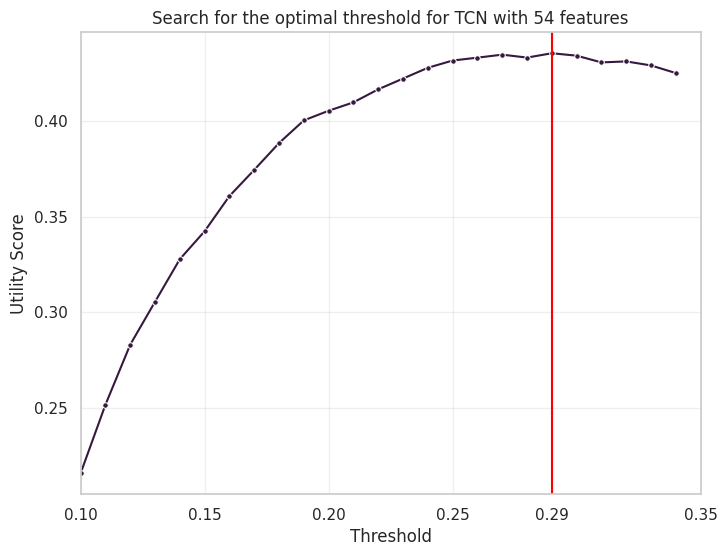

In [62]:
search_thr_graphic(hist_final, "TCN with 54 features", best_t_final)

In [63]:
test_results_final = get_tcn_predictions(model_final, test_loader_selection_wo_windows, device)

test_auprc_final, test_utility_final = evaluate_tcn_utility(
    test_results_final, 
    threshold=best_t_final, 
    label_dir='test_labels', 
    pred_dir='test_preds'
)

print(f"Test AUPRC: {test_auprc_final:.4f}")
print(f"Test Utility Score: {test_utility_final:.4f}")

Test AUPRC: 0.0921
Test Utility Score: 0.3584


In [64]:
torch.save(model_final.state_dict(), "model_final.pth")